# GoEmotions Multi-Label Emotion Classification

**Module:** CM3060  
**Task:** Comparative Text Classification (Statistical vs Deep Learning)  
**Dataset:** GoEmotions (Demszky et al., 2020)  
**Models Compared:** TF-IDF + Logistic Regression (One-vs-Rest) vs DistilBERT  

---

## Notebook Overview

This notebook presents a comparative study of multi-label emotion classification using the GoEmotions dataset.  
It combines **written analysis and executable code** in a single, structured workflow that mirrors the coursework specification.

The notebook is organised into clearly numbered sections covering:
- problem motivation and objectives,
- dataset exploration and evaluation methodology,
- model implementation and comparison,
- performance analysis and final reflections.

Code cells implement the methods described in the surrounding text, and results are analysed inline rather than deferred to the end.

---

## Reproducibility Statement

All experiments are conducted using predefined training, validation, and test splits.  
Random seeds are fixed to ensure reproducibility, and no information from the test set is used during model selection or tuning.  
Detailed environment and configuration information is provided later in the notebook.

# I. Introduction

## 1. Introduction to the Domain-Specific Area

### Motivation and Applications

Emotion detection from text is a core task within Natural Language Processing (NLP) that aims to identify affective states expressed in written language. Unlike traditional sentiment analysis, which focuses on coarse polarity categories such as positive or negative, emotion detection seeks to recognise a richer set of fine-grained emotions, including anger, joy, sadness, fear, or surprise. As large volumes of user-generated text are produced daily across online platforms, understanding emotional content has become increasingly important, while manual analysis remains impractical at scale.

In industry, emotion detection supports several applications. Content moderation systems benefit from distinguishing between forms of negative expression such as frustration, hostility, or sarcasm, rather than treating all negative content uniformly. In customer support analytics, detecting emotions such as dissatisfaction or urgency enables automated escalation and prioritisation of user queries. Emotion recognition has also been explored in mental-health-related applications, where linguistic cues may indicate distress, and in user experience research, where emotional feedback helps organisations understand user reactions to products and services. Across these domains, accurate emotion detection can improve decision-making, responsiveness, and overall system effectiveness.

### Challenges in Emotion Detection

Despite its practical value, emotion detection is challenging. A key difficulty is its inherently multi-label nature, where a single text may express multiple emotions, such as joy and surprise or anger and disappointment. This contrasts with standard single-label classification tasks and complicates both modelling and evaluation, including metric choice and thresholding.

Emotional expression in text is also highly context-dependent. Linguistic phenomena such as negation, intensifiers, irony, and sarcasm can substantially alter emotional meaning, particularly in short, informal texts common on social media. For example, phrases like “not bad at all” or “great, another meeting” require contextual interpretation beyond simple keyword matching, which is difficult for bag-of-words methods.

### Ethical Considerations

Ethical considerations are central to deploying emotion detection systems. Models trained on social media data may reflect biases associated with demographic or cultural groups, leading to uneven performance. Privacy concerns also arise when systems infer mental states without explicit user consent. There is a risk of misuse, such as profiling individuals or enabling intrusive surveillance, highlighting the need for careful dataset selection, transparent evaluation, and responsible deployment.

### Related Work and Benchmarks

Recent research has addressed these challenges through large annotated datasets and advances in modelling techniques. The GoEmotions dataset introduced by Demszky et al. (2020) provides fine-grained, human-annotated emotion labels for social media text and has become a standard benchmark. Earlier surveys describe emotion detection as a long-standing NLP problem due to ambiguity and label overlap (Sailunaz & Alhajj, 2019; Mohammad, 2016). Research on multi-label learning formalises methods for handling overlapping labels (Zhang & Zhou, 2014), while transformer-based models demonstrate improved contextual language understanding for emotion recognition (Devlin et al., 2019; Liu et al., 2019). This project compares statistical and transformer-based approaches for multi-label emotion detection using GoEmotions.

## 2. Objectives of the Project

The primary objective of this project is to develop a multi-label emotion classification system capable of identifying fine-grained emotional states expressed in short, informal text. Using the GoEmotions dataset, the project aims to move beyond coarse sentiment polarity and instead predict multiple, non-mutually exclusive emotion labels for each text instance. This reflects the complexity of real-world emotional expression, where individuals often convey overlapping emotions such as joy and surprise or anger and disappointment within a single utterance. Addressing this task requires models that can handle label overlap, class imbalance, and subtle linguistic cues while preserving emotional information.

A central objective of the project is to conduct a systematic comparative evaluation between two fundamentally different modelling paradigms. The first is a traditional statistical approach based on TF-IDF feature representations combined with a One-vs-Rest Logistic Regression classifier. The second is a modern embedding-based deep learning approach that fine-tunes a transformer model, specifically DistilBERT, for multi-label emotion classification. By evaluating these models under a consistent experimental setup, the project seeks to quantify performance differences between lightweight, interpretable statistical models and more expressive contextual models, clarifying when the additional computational cost of transformer-based methods is justified.

Another key objective of the project is to employ evaluation methodologies that are appropriate for multi-label classification problems. Unlike single-label tasks, multi-label classification requires metrics that account for partial correctness and class imbalance. Accordingly, this project emphasises metrics such as micro-F1, macro-F1, Hamming loss, and subset accuracy. Particular importance is placed on macro-F1, as it treats all emotion labels equally and provides insight into performance on rare emotions that may be overlooked by aggregate metrics dominated by frequent labels. In addition, the project analyses the impact of decision thresholds by performing validation-based threshold tuning.

Beyond aggregate evaluation metrics, the project also aims to conduct detailed quantitative and qualitative error analysis. Quantitative analysis includes per-label performance breakdowns to identify which emotions are consistently easy or difficult to predict. Qualitative analysis involves manual inspection of selected prediction errors to uncover common failure patterns, such as misinterpretation of negation, sarcasm, or ambiguous emotional boundaries. This combined analysis provides deeper insight into model behaviour and limitations not visible from summary metrics alone.

Finally, ensuring reproducibility and methodological rigour is a core objective of this project. All experiments are conducted using predefined training, validation, and test splits, with fixed random seeds and clearly documented preprocessing, training, and evaluation procedures. Maintaining a transparent and repeatable pipeline ensures that results are reliable and suitable for future comparison.

**Explicit project objectives:**
- To build a multi-label emotion classification system using the GoEmotions dataset.  
- To compare a statistical TF-IDF–based model with a transformer-based deep learning model.  
- To apply and justify evaluation metrics suitable for multi-label emotion classification.  
- To perform quantitative and qualitative error analysis to understand model behaviour.  
- To ensure reproducibility through controlled data splits and documented methodology.

## 3. Dataset Description

### Dataset Origin and Purpose

This project uses the GoEmotions dataset introduced by Demszky et al. (2020), a large-scale, human-annotated dataset designed for fine-grained emotion classification in text. The dataset is constructed from Reddit comments and provides one of the most comprehensive emotion annotation schemes currently available in natural language processing research. Unlike earlier emotion datasets that focus on a small number of categories or assume mutually exclusive labels, GoEmotions explicitly supports multi-label emotion classification, allowing each text instance to be associated with multiple emotional states.

### Data Source and Official Splits

The dataset was originally released by Google Research and is publicly available for research use. In this project, the dataset is accessed via preprocessed and simplified split files that preserve the original training, validation, and test partitions defined by the dataset authors. Using the official splits ensures consistency with prior work and prevents data leakage between training and evaluation stages.

### Dataset Size and Structure

GoEmotions contains approximately 58,000 Reddit comments, divided into three subsets: a training set of around 43,000 samples, a validation set of approximately 5,400 samples, and a test set of approximately 5,400 samples. Each instance consists of a short text comment and a corresponding set of emotion labels. Text data are stored as strings, while labels are represented as lists of emotion identifiers and later converted into multi-hot encoded vectors during preprocessing. This representation supports flexible modelling of overlapping emotional expressions.

### Label Space and Multi-Label Characteristics

The label space comprises 27 fine-grained emotion categories, such as admiration, amusement, anger, fear, sadness, and surprise, along with a neutral category, resulting in a total of 28 labels. Labels are not mutually exclusive, meaning a single comment may simultaneously express multiple emotions, such as joy and surprise or anger and disappointment. This structure reflects real-world emotional expression but also increases task complexity compared to standard single-label emotion or sentiment classification tasks.

### Exploratory Data Analysis Overview

Exploratory data analysis (EDA) examines label frequency, labels per sample, text length, and label co-occurrence. The results show strong class imbalance, with a few dominant emotions, frequent multi-label samples, and short, informal Reddit text that relies heavily on context.

### Dataset Limitations

Despite its scale, GoEmotions has limitations. The Reddit-only source restricts domain generalisation, and emotion annotation remains subjective, particularly for ambiguous expressions. These factors must be considered when interpreting model performance.

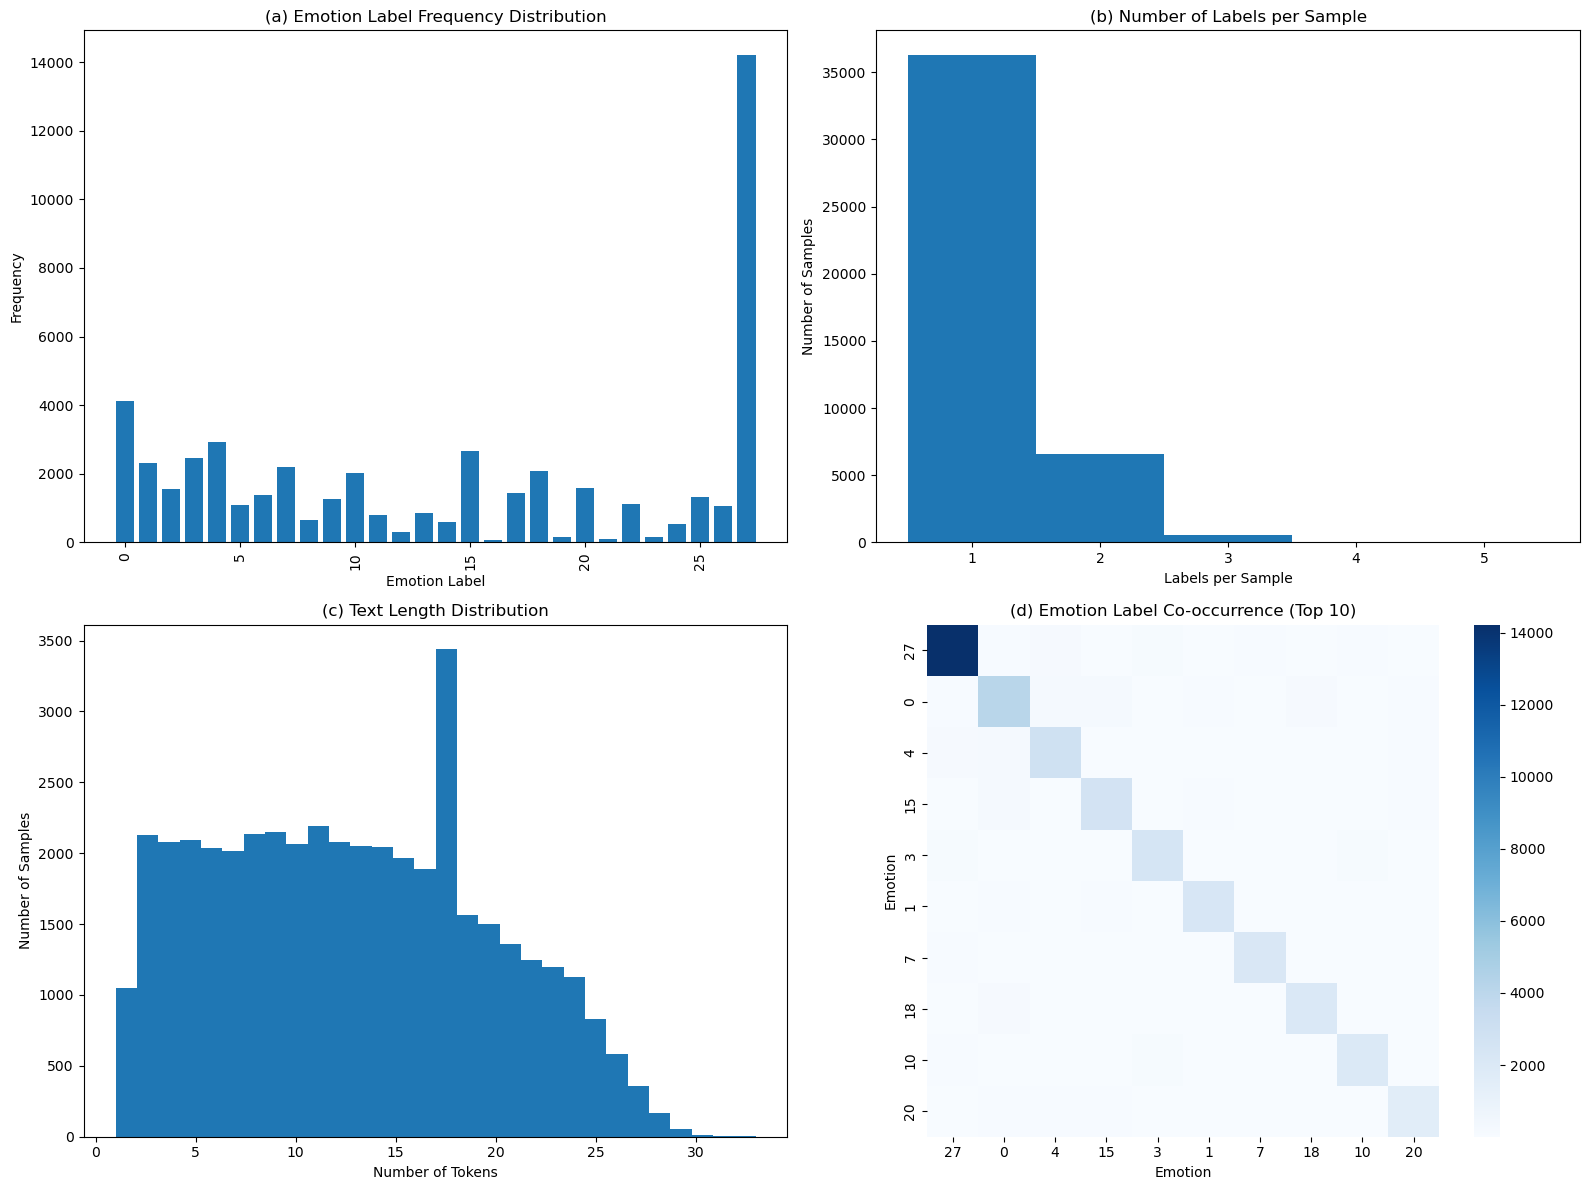

In [775]:
# Exploratory Data Analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# --------- Prepare data ---------

# Flatten labels
all_labels = []
for labels in train_df["labels"]:
    all_labels.extend(labels)

label_counts = Counter(all_labels)
label_freq_df = (
    pd.DataFrame(label_counts.items(), columns=["label", "count"])
    .sort_values("count", ascending=False)
)

# Labels per sample
labels_per_sample = train_df["labels"].apply(len)

# Text length (simple whitespace tokenisation)
text_lengths = train_df["text"].apply(lambda x: len(str(x).split()))

# Top-k labels for co-occurrence
TOP_K = 10
top_k_labels = label_freq_df["label"].head(TOP_K).tolist()

co_occurrence = pd.DataFrame(
    0, index=top_k_labels, columns=top_k_labels
)

for labels in train_df["labels"]:
    filtered = [l for l in labels if l in top_k_labels]
    for i in filtered:
        for j in filtered:
            co_occurrence.loc[i, j] += 1

# --------- Plot ---------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Label frequency
axes[0, 0].bar(label_freq_df["label"], label_freq_df["count"])
axes[0, 0].set_title("(a) Emotion Label Frequency Distribution")
axes[0, 0].set_xlabel("Emotion Label")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].tick_params(axis="x", rotation=90)

# (b) Labels per sample
axes[0, 1].hist(
    labels_per_sample,
    bins=range(1, labels_per_sample.max() + 2),
    align="left"
)
axes[0, 1].set_title("(b) Number of Labels per Sample")
axes[0, 1].set_xlabel("Labels per Sample")
axes[0, 1].set_ylabel("Number of Samples")

# (c) Text length distribution
axes[1, 0].hist(text_lengths, bins=30)
axes[1, 0].set_title("(c) Text Length Distribution")
axes[1, 0].set_xlabel("Number of Tokens")
axes[1, 0].set_ylabel("Number of Samples")

# (d) Label co-occurrence
sns.heatmap(
    co_occurrence,
    ax=axes[1, 1],
    cmap="Blues",
    square=True,
    cbar=True
)
axes[1, 1].set_title("(d) Emotion Label Co-occurrence (Top 10)")
axes[1, 1].set_xlabel("Emotion")
axes[1, 1].set_ylabel("Emotion")

plt.tight_layout()
plt.show()

### Exploratory Data Analysis Summary

Four exploratory plots are used to characterise the GoEmotions dataset:

- **Emotion label frequency plot** shows a strong long-tail distribution, with neutral and a few emotions appearing very frequently, while many emotions are rare, highlighting severe class imbalance.
- **Labels-per-sample histogram** confirms that most texts contain a single emotion label, but a meaningful subset expresses multiple emotions, reinforcing the multi-label nature of the task.
- **Text length distribution** indicates that Reddit comments are generally short and informal, typically containing fewer than 30 tokens, which increases reliance on contextual understanding.
- **Label co-occurrence heatmap** reveals common emotion pairings, demonstrating that certain emotions frequently appear together rather than in isolation.

## 4. Evaluation Methodology

### Task Formulation

This project formulates emotion detection as a multi-label text classification problem. Unlike multi-class classification, where each input is assigned exactly one label, multi-label classification allows each text instance to be associated with zero, one, or multiple emotion labels simultaneously. This formulation reflects real-world emotional expression, where emotions frequently co-occur and are not mutually exclusive. As a result, evaluation strategies must account for partial correctness, overlapping labels, and class imbalance rather than relying on single-label accuracy.

### Evaluation Metrics

To evaluate model performance appropriately, this project adopts metrics specifically designed for multi-label classification. Micro-averaged F1 score is used to measure overall performance by aggregating true positives, false positives, and false negatives across all labels. This metric is sensitive to frequent labels and provides a global view of model effectiveness. Macro-averaged F1 score is also reported, as it computes the F1 score independently for each emotion label and then averages them equally. Macro-F1 is particularly important for this task because it highlights performance on rare emotions that may otherwise be overshadowed by dominant labels such as neutral. In addition, Hamming loss is used to quantify the fraction of incorrect label assignments, offering an interpretable measure of prediction error across labels. Subset accuracy, which requires an exact match between predicted and true label sets, is included for completeness, although it is expected to be low due to the strictness of the metric in multi-label settings.

### Threshold Selection

Since models produce probabilistic outputs for each emotion label, a decision threshold is required to convert probabilities into binary predictions. While a default threshold of 0.5 is commonly used, this value is not necessarily optimal for imbalanced multi-label datasets. Therefore, this project adopts a validation-based threshold tuning strategy. Thresholds are selected by evaluating performance on the validation set and choosing the value that maximises macro-F1 score. This approach ensures that threshold selection is data-driven and aligned with the objective of balanced performance across all emotions. Threshold tuning is performed exclusively on the validation set to avoid test-set leakage.

### Validation Protocol

The validation protocol follows a strict separation of training, validation, and test data. Model training and hyperparameter tuning are conducted using the training and validation sets only. The test set is held out entirely and used exactly once for final evaluation after all modelling decisions have been fixed. This protocol prevents optimistic bias and ensures that reported test results reflect genuine generalisation performance rather than overfitting to evaluation data.

### Reporting and Error Analysis

In addition to aggregate metrics, the evaluation framework emphasises robust and interpretable reporting. Results are presented using metric tables, per-label performance summaries, and selected prediction examples. Error analysis is conducted to identify systematic failure patterns, such as confusion between similar emotions, sensitivity to negation, or difficulty with sarcastic expressions. Together, these evaluation choices provide a comprehensive and principled assessment of model behaviour, ensuring that conclusions are grounded in both quantitative performance and qualitative insight.


# II. Implementation

## Implementation Setup

This section defines the execution environment used throughout the implementation. Core libraries, random seeds, and global configuration settings are initialised once to ensure consistent behaviour and reproducibility across all subsequent preprocessing and modelling steps.

In [781]:
# =============================
# Implementation Setup
# =============================
import numpy as np
import pandas as pd
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## 5. Data Preprocessing

Data preprocessing plays a critical role in the performance and reliability of text classification systems, particularly for multi-label emotion detection tasks. In this project, preprocessing is designed to preserve the semantic and emotional content of short, informal text while preparing the data for both statistical and transformer-based models. Overly aggressive cleaning is avoided, as phenomena such as negation, sarcasm, and intensifiers are central to emotional meaning and were identified as key challenges in earlier sections.

Preprocessing is performed with careful consideration of the differing requirements of the two model families evaluated in this project. Statistical models based on TF-IDF representations rely on explicit token frequency information, while transformer-based models such as DistilBERT operate on subword tokenisation and contextual embeddings. As a result, certain preprocessing steps are shared across models, while others are model-specific and applied separately.

In addition to text processing, this section addresses label encoding for multi-label classification, handling of class imbalance, and safeguards against data leakage. All preprocessing steps are applied consistently across predefined training, validation, and test splits to ensure methodological rigour and reproducibility. Together, these choices establish a clean and controlled input pipeline that supports fair model comparison and reliable evaluation as defined in Section 4.

### 5.1 Data Loading and Integrity Checks

The first step in the preprocessing pipeline is to load the dataset and verify its structural integrity. Ensuring that the data are correctly loaded and free from basic issues such as missing values, duplicate entries, or schema inconsistencies is essential before any further processing. Undetected data quality issues at this stage can propagate through the pipeline and invalidate downstream evaluation.

For each dataset split (training, validation, and test), integrity checks are performed to confirm the presence of the required columns, verify that text entries are non-null, and ensure that emotion labels are available in the expected format. Duplicate text instances are also inspected to avoid unintended bias during training or evaluation. These checks establish a reliable and consistent foundation for subsequent preprocessing steps.

In [785]:
# -----------------------------
# Load dataset splits (Parquet)
# -----------------------------
train_df = pd.read_parquet("Data/train-00000-of-00001.parquet")
val_df   = pd.read_parquet("Data/validation-00000-of-00001.parquet")
test_df  = pd.read_parquet("Data/test-00000-of-00001.parquet")

# -----------------------------
# Basic integrity checks
# -----------------------------
def integrity_check(df, name):
    print(f"--- {name} set ---")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Null values:\n", df.isnull().sum())
    print("Duplicate texts:", df["text"].duplicated().sum())
    print()

integrity_check(train_df, "Training")
integrity_check(val_df, "Validation")
integrity_check(test_df, "Test")

# -----------------------------
# Ensure required columns exist
# -----------------------------
required_columns = {"text", "labels"}

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"{split_name} set missing columns: {missing}")

--- Training set ---
Shape: (43410, 3)
Columns: ['text', 'labels', 'id']
Null values:
 text      0
labels    0
id        0
dtype: int64
Duplicate texts: 183

--- Validation set ---
Shape: (5426, 3)
Columns: ['text', 'labels', 'id']
Null values:
 text      0
labels    0
id        0
dtype: int64
Duplicate texts: 3

--- Test set ---
Shape: (5427, 3)
Columns: ['text', 'labels', 'id']
Null values:
 text      0
labels    0
id        0
dtype: int64
Duplicate texts: 6



#### Integrity check summary
No missing values were observed across any dataset split. A small number of duplicate text entries were detected within each split, which is consistent with the original GoEmotions dataset and does not indicate data leakage across training, validation, and test sets. These duplicates are retained to preserve the integrity of the official dataset splits and ensure comparability with prior work.

### 5.2 Label Processing and Encoding

GoEmotions is formulated as a multi-label classification task, where each text instance may be associated with multiple emotion labels. To support this setting, emotion labels are converted from list-based representations into fixed-length multi-hot encoded vectors, where each dimension corresponds to one emotion category.

Multi-hot encoding enables independent prediction of each emotion label and is compatible with both the statistical and transformer-based models evaluated in this project. This representation also aligns with the evaluation methodology defined in Section 4, which treats each label independently when computing multi-label performance metrics. Label encoding is performed consistently across training, validation, and test sets using a shared label index mapping derived from the dataset.

In [789]:
# -----------------------------
# Build label index mapping
# -----------------------------
# Extract all unique labels from the training set
all_labels = set()
for labels in train_df["labels"]:
    all_labels.update(labels)

# Sort labels to ensure consistent ordering
label_list = sorted(all_labels)
num_labels = len(label_list)

label_to_index = {label: idx for idx, label in enumerate(label_list)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

print(f"Number of labels: {num_labels}")

# -----------------------------
# Multi-hot encoding function
# -----------------------------
def multi_hot_encode(label_lists, label_to_index, num_labels):
    encoded = np.zeros((len(label_lists), num_labels), dtype=int)
    for i, labels in enumerate(label_lists):
        for label in labels:
            encoded[i, label_to_index[label]] = 1
    return encoded

# -----------------------------
# Encode labels for each split
# -----------------------------
y_train = multi_hot_encode(train_df["labels"], label_to_index, num_labels)
y_val   = multi_hot_encode(val_df["labels"], label_to_index, num_labels)
y_test  = multi_hot_encode(test_df["labels"], label_to_index, num_labels)

# -----------------------------
# Sanity checks
# -----------------------------
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

# Check average number of labels per sample
print("Average labels per training sample:", y_train.sum(axis=1).mean())

Number of labels: 28
y_train shape: (43410, 28)
y_val shape: (5426, 28)
y_test shape: (5427, 28)
Average labels per training sample: 1.1772172310527529


#### Label encoding summary
Multi-hot encoding produced fixed-length label vectors with 28 dimensions, corresponding to the full GoEmotions label set. The average number of labels per training sample is approximately 1.18, confirming that most instances express a single emotion while a meaningful subset exhibits overlapping emotional states, consistent with the multi-label nature of the dataset.

### 5.3 Text Cleaning

Text cleaning is performed to normalise surface-level variations while preserving the semantic and emotional content of each text instance. Given the importance of negation, sarcasm, and intensifiers in emotion detection, only minimal and justified preprocessing steps are applied. Aggressive cleaning techniques such as stopword removal or punctuation stripping are deliberately avoided, as they may remove linguistically meaningful cues.

The applied cleaning steps include lowercasing text, replacing URLs with a placeholder token, and removing excess whitespace. These operations reduce noise and standardise input without altering the underlying meaning of the text. The same cleaning procedure is applied consistently across all dataset splits to maintain comparability and avoid data leakage.

In [793]:
import re

# -----------------------------
# Text cleaning function
# -----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "<url>", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# -----------------------------
# Apply cleaning to all splits
# -----------------------------
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"]   = val_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

# -----------------------------
# Display examples (before vs after)
# -----------------------------
train_df[["text", "clean_text"]].head()

,text,clean_text
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn't have to...
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin..."
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing
3,To make her feel threatened,to make her feel threatened
4,Dirty Southern Wankers,dirty southern wankers


### 5.4 Tokenisation

Tokenisation converts cleaned text into numerical representations that can be consumed by machine learning models. As this project evaluates two different model families, tokenisation is performed using model-specific approaches rather than a single unified pipeline.

Statistical models based on TF-IDF rely on explicit token frequency information and operate on word-level n-grams. In contrast, transformer-based models such as DistilBERT use subword tokenisation to handle vocabulary coverage and contextual representation. To ensure fair comparison and correct model behaviour, tokenisation is performed separately for each model family while sharing the same cleaned text input.

#### 5.4.1 TF-IDF Tokenisation

For the statistical baseline, text is represented using Term Frequency–Inverse Document Frequency (TF-IDF) features. This representation captures the importance of words and short phrases based on their frequency within a document and rarity across the corpus. Word-level n-grams are used to model short contextual patterns while maintaining interpretability.

TF-IDF vectorisation is fitted exclusively on the training data to prevent information leakage. The learned vocabulary and weighting scheme are then applied unchanged to the validation and test sets.

In [797]:
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------
# TF-IDF configuration
# -----------------------------
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=5,
    max_features=20000
)

# -----------------------------
# Fit on training data only
# -----------------------------
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_text"])
X_val_tfidf   = tfidf_vectorizer.transform(val_df["clean_text"])
X_test_tfidf  = tfidf_vectorizer.transform(test_df["clean_text"])

# -----------------------------
# Sanity check
# -----------------------------
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF validation shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (43410, 19028)
TF-IDF validation shape: (5426, 19028)
TF-IDF test shape: (5427, 19028)


TF-IDF vectorisation is fitted exclusively on the training data, with the learned vocabulary and weighting scheme applied unchanged to the validation and test sets to prevent information leakage.

#### 5.4.2 Transformer Tokenisation

For the transformer-based model, tokenisation is performed using the pretrained DistilBERT tokenizer. Unlike TF-IDF, transformer models operate on subword units, allowing them to handle out-of-vocabulary words and capture contextual meaning more effectively.

The tokenizer converts cleaned text into input IDs and attention masks required by the model. Sequences are padded and truncated to a fixed maximum length to ensure uniform tensor shapes. Tokenisation is applied consistently across training, validation, and test sets using the same pretrained tokenizer to maintain comparability and prevent data leakage.

In [801]:
from transformers import DistilBertTokenizerFast

# -----------------------------
# Load pretrained tokenizer
# -----------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

MAX_LEN = 128

# -----------------------------
# Tokenisation function
# -----------------------------
def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

# -----------------------------
# Apply tokenisation to splits
# -----------------------------
train_encodings = tokenize_texts(train_df["clean_text"].tolist())
val_encodings   = tokenize_texts(val_df["clean_text"].tolist())
test_encodings  = tokenize_texts(test_df["clean_text"].tolist())

# -----------------------------
# Sanity check
# -----------------------------
print("Train input_ids shape:", train_encodings["input_ids"].shape)
print("Train attention_mask shape:", train_encodings["attention_mask"].shape)

Train input_ids shape: torch.Size([43410, 128])
Train attention_mask shape: torch.Size([43410, 128])


The same pretrained DistilBERT tokenizer is reused across all dataset splits, ensuring consistent subword representations and avoiding any data-dependent tokenisation.

### 5.5 Class Imbalance Handling

The GoEmotions dataset exhibits substantial class imbalance, with a small number of frequent emotions (including *neutral*) and many rare emotion labels. In multi-label settings, such imbalance can bias models towards dominant labels and obscure performance on less frequent emotions if not explicitly addressed.

Rather than altering the data distribution through resampling, this project adopts model-appropriate strategies for handling imbalance while preserving the original dataset structure. For statistical models, class imbalance is addressed through class-weighted learning, ensuring that errors on rare labels receive higher importance during training. For transformer-based models, imbalance is primarily handled at the evaluation stage through the use of macro-averaged metrics and validation-based threshold tuning, as described in Section 4.

This approach maintains methodological consistency across training, validation, and test sets, avoids introducing artificial data artifacts, and aligns with the evaluation objectives of balanced per-label performance and fair model comparison.

In [805]:
# --------------------------------
# Compute class weights (training set only)
# --------------------------------
label_frequencies = y_train.sum(axis=0)
num_samples = y_train.shape[0]

class_weights = {
    i: num_samples / (len(label_frequencies) * freq)
    for i, freq in enumerate(label_frequencies)
}

# Sanity check: show a few weights
for i in range(5):
    print(f"Label {i} weight: {class_weights[i]:.3f}")

Label 0 weight: 0.375
Label 1 weight: 0.666
Label 2 weight: 0.989
Label 3 weight: 0.628
Label 4 weight: 0.528


### 5.6 Leakage Prevention

To ensure valid and unbiased evaluation, strict safeguards are applied throughout preprocessing to prevent information leakage between training, validation, and test sets. All preprocessing steps are performed with clear separation between dataset splits, and no information from the validation or test sets is used during model fitting or parameter selection.

Text cleaning and label encoding are applied independently but consistently across all splits using identical procedures. Feature extraction steps that involve learning parameters from data, such as TF-IDF vectorisation, are fitted exclusively on the training set, with the learned representations applied unchanged to the validation and test sets. Similarly, class imbalance statistics and class weights are computed using training data only.

For transformer-based models, the same pretrained tokenizer is reused across all splits without adaptation to dataset-specific distributions. Model selection decisions, including threshold tuning, are based solely on validation performance, while the test set is held out entirely and used only once for final evaluation.

These measures ensure that reported results reflect genuine generalisation performance rather than inadvertent exposure to evaluation data.

### 5.7 Reproducibility Controls

To ensure that experimental results are reproducible, all sources of randomness are explicitly controlled and the execution environment is kept consistent across runs. Random seeds are fixed for all relevant libraries at the start of the implementation, ensuring that preprocessing, model initialisation, and training behaviour remain stable.

Dataset splits follow the predefined training, validation, and test partitions provided with the GoEmotions dataset and are never reshuffled. All preprocessing operations, feature extraction steps, and tokenisation procedures are deterministic and applied identically across runs.

In addition, all model configurations, hyperparameters, and preprocessing settings are explicitly defined in code rather than relying on implicit defaults. Together, these measures ensure that reported results can be reliably reproduced and fairly compared, supporting methodological rigour and transparency.

## 6. Baseline Performance

Baseline models provide reference points against which more complex approaches can be evaluated. In this project, baselines are used to establish minimum performance expectations for multi-label emotion classification on the GoEmotions dataset and to contextualise the gains achieved by more expressive models in later sections.

Two types of baselines are considered. First, a naive baseline is introduced as a sanity check, reflecting performance achievable without meaningful language understanding. Second, a statistical baseline based on TF-IDF representations and a One-vs-Rest classifier is implemented to capture surface-level lexical patterns while remaining computationally efficient and interpretable.

Baseline performance is evaluated using the same multi-label metrics defined in Section 4 to ensure fair comparison. Results are analysed quantitatively through aggregate metrics and per-label performance, and qualitatively through selected prediction errors, highlighting the strengths and limitations of simple models in emotion detection.

### 6.1 Naive Baseline

A naive baseline is used to establish a minimum performance reference for the task. This baseline makes predictions without modelling linguistic content, serving as a sanity check for the evaluation pipeline.

In this implementation, the naive model predicts the single most frequent emotion label from the training set for every sample. While unrealistic, this approach highlights the impact of class imbalance and demonstrates how misleading aggregate metrics can be when rare labels are ignored.

In [811]:
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

# -----------------------------
# Identify most frequent label
# -----------------------------
label_counts = y_train.sum(axis=0)
most_frequent_label = np.argmax(label_counts)

print("Most frequent label index:", most_frequent_label)

# -----------------------------
# Naive predictions
# -----------------------------
def naive_predict(y_true, label_index):
    y_pred = np.zeros_like(y_true)
    y_pred[:, label_index] = 1
    return y_pred

y_val_naive = naive_predict(y_val, most_frequent_label)

# -----------------------------
# Evaluation metrics
# -----------------------------
metrics_naive = {
    "micro_f1": f1_score(y_val, y_val_naive, average="micro"),
    "macro_f1": f1_score(y_val, y_val_naive, average="macro"),
    "hamming_loss": hamming_loss(y_val, y_val_naive),
    "subset_accuracy": accuracy_score(y_val, y_val_naive)
}

metrics_naive

Most frequent label index: 27


{'micro_f1': 0.29916991360325257,
 'macro_f1': 0.017539329413634196,
 'hamming_loss': 0.05446000737191301,
 'subset_accuracy': 0.2934021378547733}

#### Naive Baseline Results
The naive baseline predicts the single most frequent emotion label for all validation samples. As expected, this approach performs poorly on balanced metrics.

The relatively higher **micro-F1 (≈0.30)** and **subset accuracy (≈0.29)** reflect the dominance of the most frequent label in the dataset. In contrast, the extremely low **macro-F1 (≈0.02)** highlights the model’s complete failure to identify rare emotion classes, as all other labels are ignored.

These results confirm the strong class imbalance present in the GoEmotions dataset and demonstrate why aggregate metrics alone can be misleading in multi-label settings. This baseline establishes a lower bound on performance and motivates the need for more expressive models.

### 6.2 Statistical Baseline Model

As a stronger baseline, a linear statistical classifier is trained using TF-IDF features. 
A One-vs-Rest Logistic Regression model is used to handle the multi-label nature of the GoEmotions dataset, 
where a separate binary classifier is trained for each emotion label.

This model incorporates linguistic information through TF-IDF representations while remaining interpretable 
and computationally efficient. Class imbalance is addressed through class-weighted loss, ensuring that rare 
emotion labels contribute proportionally during training. Performance is evaluated on the validation set using 
the same metrics as the naive baseline for fair comparison.

In [815]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

# -----------------------------
# Train One-vs-Rest Logistic Regression
# -----------------------------
logreg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

ovr_clf = OneVsRestClassifier(logreg)
ovr_clf.fit(X_train_tfidf, y_train)

# -----------------------------
# Predict on validation set
# -----------------------------
y_val_pred = ovr_clf.predict(X_val_tfidf)

# -----------------------------
# Evaluation metrics
# -----------------------------
metrics_logreg = {
    "micro_f1": f1_score(y_val, y_val_pred, average="micro"),
    "macro_f1": f1_score(y_val, y_val_pred, average="macro"),
    "hamming_loss": hamming_loss(y_val, y_val_pred),
    "subset_accuracy": accuracy_score(y_val, y_val_pred)
}

metrics_logreg

{'micro_f1': 0.48752182975607006,
 'macro_f1': 0.4385010164137178,
 'hamming_loss': 0.059877047022273706,
 'subset_accuracy': 0.2141540729819388}

#### Statistical Baseline Results

The TF-IDF + One-vs-Rest Logistic Regression model demonstrates a substantial improvement over the naive baseline across all evaluation metrics.

The **micro-F1 score (≈0.49)** indicates that the model correctly predicts a large proportion of label assignments overall, reflecting its ability to exploit frequent emotion patterns in the dataset. More importantly, the **macro-F1 score (≈0.44)** represents a dramatic improvement compared to the naive baseline, showing that the model is now able to identify a wide range of emotion classes, including less frequent labels.

The **Hamming loss (≈0.06)** suggests that only a small fraction of individual label predictions are incorrect, indicating stable per-label performance across samples. In contrast, the **subset accuracy (≈0.21)** remains relatively low, which is expected in multi-label emotion classification due to the strict requirement that *all* labels for a sample must be predicted correctly.

Overall, these results confirm that incorporating linguistic features through TF-IDF representations enables meaningful emotion recognition beyond the dominant class. However, the model remains limited by its linear decision boundaries and lack of contextual understanding, motivating the use of transformer-based approaches in later sections.

### 6.3 Baseline Results

This section summarises the performance of the naive baseline and the TF-IDF + Logistic Regression baseline using the evaluation metrics defined in Section 4. Presenting the results side by side highlights the extent to which incorporating lexical features improves multi-label emotion classification performance.

In [818]:
# -----------------------------
# Baseline comparison table
# -----------------------------
baseline_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "TF-IDF + Logistic Regression"
    ],
    "Micro-F1": [
        metrics_naive["micro_f1"],
        metrics_logreg["micro_f1"]
    ],
    "Macro-F1": [
        metrics_naive["macro_f1"],
        metrics_logreg["macro_f1"]
    ],
    "Hamming Loss": [
        metrics_naive["hamming_loss"],
        metrics_logreg["hamming_loss"]
    ],
    "Subset Accuracy": [
        metrics_naive["subset_accuracy"],
        metrics_logreg["subset_accuracy"]
    ]
})

baseline_results

,Model,Micro-F1,Macro-F1,Hamming Loss,Subset Accuracy
0,Naive Baseline,0.299170,0.017539,0.054460,0.293402
1,TF-IDF + Logistic Regression,0.487522,0.438501,0.059877,0.214154


The results show a clear performance gap between the naive baseline and the TF-IDF–based statistical model. While the naive approach achieves non-trivial micro-F1 by exploiting class imbalance, it fails to recognise most emotion labels, as reflected by its extremely low macro-F1.

In contrast, the TF-IDF + Logistic Regression model achieves substantially higher macro-F1, indicating improved recognition of a broader range of emotions and demonstrating the value of incorporating lexical features.

#### Per-Label Performance Analysis (TF-IDF + Logistic Regression)

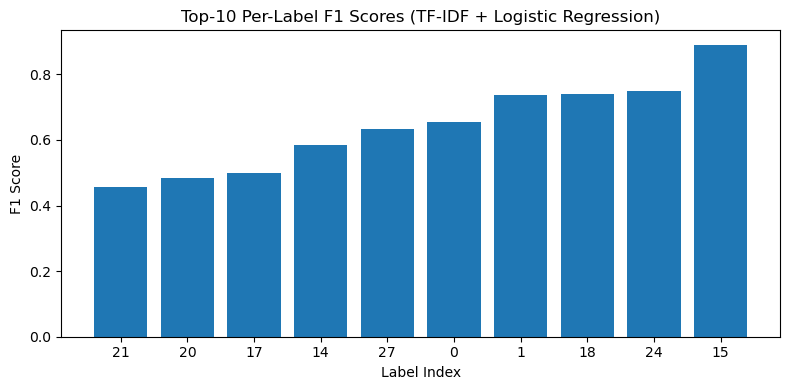

In [821]:
# -----------------------------
# Per-label F1 analysis (TF-IDF baseline)
# -----------------------------
from sklearn.metrics import f1_score

# Compute F1 score for each emotion label
per_label_f1 = f1_score(y_val, y_val_pred, average=None)

# Select top-k labels by F1 score›
TOP_K = 10
top_k_idx = np.argsort(per_label_f1)[-TOP_K:]

# Plot top-k per-label F1 scores
plt.figure(figsize=(8, 4))
plt.bar(
    [str(i) for i in top_k_idx],
    per_label_f1[top_k_idx]
)
plt.xlabel("Label Index")
plt.ylabel("F1 Score")
plt.title("Top-10 Per-Label F1 Scores (TF-IDF + Logistic Regression)")
plt.tight_layout()
plt.show()

The per-label F1 analysis highlights how performance varies across emotion categories. The statistical model performs best on frequent and lexically distinctive emotions, which benefit from consistent word-level patterns captured by TF-IDF features. In contrast, performance remains weaker on rare or semantically overlapping labels, reflecting the inherent difficulty of distinguishing subtle emotional nuances using surface-level features alone.

### 6.4 Baseline Limitations

Despite providing a meaningful reference point, the TF-IDF + Logistic Regression baseline exhibits several important limitations when applied to multi-label emotion classification.

First, the model relies entirely on surface-level lexical features. TF-IDF representations ignore word order, compositional structure, and contextual dependencies, making them incapable of modelling negation, sarcasm, or subtle emotional shifts. As a result, emotionally nuanced expressions are often misclassified.

Second, the One-vs-Rest formulation assumes conditional independence between emotion labels. In the GoEmotions dataset, many emotions frequently co-occur or overlap semantically (e.g., *joy* and *love*, *anger* and *annoyance*). Treating each label independently limits the model’s ability to capture such relationships.

Third, although class weighting partially mitigates class imbalance, performance on rare emotion labels remains weak. Labels with limited training examples or overlapping lexical cues are particularly difficult to distinguish using bag-of-words features alone.

Finally, the use of fixed decision thresholds restricts flexibility in balancing precision and recall across labels, often leading to conservative predictions and reduced recall for minority classes.

These limitations motivate the use of transformer-based models, which are better suited to capturing contextual meaning and complex label interactions in multi-label emotion classification tasks.

#### Baseline Error Examples

To further illustrate the limitations of the statistical baseline, a small number of misclassified validation examples are shown below. These examples highlight common failure cases, including missed rare emotions, overlapping emotional states, and context-dependent expressions that are difficult to capture using TF-IDF features alone.

In [828]:
# -----------------------------
# Baseline error examples
# -----------------------------

# Identify misclassified validation samples
errors = np.where((y_val != y_val_pred).any(axis=1))[0]

# Display a few error cases
NUM_EXAMPLES = 5
error_examples = errors[:NUM_EXAMPLES]

for idx in error_examples:
    print("Text:")
    print(val_df.iloc[idx]["text"])
    print("True labels:", np.where(y_val[idx] == 1)[0])
    print("Predicted labels:", np.where(y_val_pred[idx] == 1)[0])
    print("-" * 80)

Text:
Is this in New Orleans?? I really feel like this is New Orleans.
True labels: [27]
Predicted labels: [7]
--------------------------------------------------------------------------------
Text:
You know the answer man, you are programmed to capture those codes they send you, don’t avoid them!
True labels: [ 4 27]
Predicted labels: [ 3 10 27]
--------------------------------------------------------------------------------
Text:
I've never been this sad in my life!
True labels: [25]
Predicted labels: [ 9 22 25]
--------------------------------------------------------------------------------
Text:
The economy is heavily controlled and subsidized by the government. In any case, I was poking at the lack of nuance in US politics today
True labels: [ 4 27]
Predicted labels: [27]
--------------------------------------------------------------------------------
Text:
He could have easily taken a real camera from a legitimate source and change the price in Word/Photoshop and then print it out

#### Baseline Error Analysis (Validation Set)
The examples above illustrate common failure modes of the TF-IDF + Logistic Regression baseline. Errors frequently involve rare emotion labels, overlapping emotional states, and context-dependent expressions where surface-level lexical features are insufficient. These qualitative observations are used solely for analysis; no model parameters were adjusted based on these examples.

## 7. Comparative Classification Methodology

This section presents the core experimental work of the project. It implements, trains, and evaluates two fundamentally different approaches to multi-label emotion classification: a traditional statistical model and a transformer-based deep learning model.

Both model families are evaluated under a controlled and consistent experimental setup to ensure a fair comparison. Training is performed on the predefined training split, model selection and threshold tuning are conducted using the validation split, and final performance is reported on the held-out test set only.

All evaluation metrics, thresholding strategies, and validation protocols follow the methodology defined in Section 4. No information from the test set is used during training or model selection.

### 7.1 Overview of Comparative Setup

This subsection outlines the experimental design used to compare the statistical and transformer-based classification models. The objective is to ensure that performance differences between models can be attributed to modelling choices rather than inconsistencies in data handling or evaluation.

Both models are trained, validated, and tested using the same predefined data splits introduced in Section 3. Model training is conducted exclusively on the training set, while the validation set is used for hyperparameter selection and decision threshold tuning. The test set is held out entirely and used only once for final performance evaluation.

To maintain comparability, all models are evaluated using the same multi-label metrics described in Section 4, including micro-F1, macro-F1, Hamming loss, and subset accuracy. Decision thresholds are selected using validation-based tuning, with macro-F1 used as the primary optimisation criterion to account for class imbalance.

No test-set information is used during model training, hyperparameter tuning, or threshold selection. This controlled setup ensures a fair and reproducible comparison between the statistical and embedding-based approaches.

### 7.2 Statistical Model: TF-IDF + Logistic Regression
This subsection implements a traditional statistical approach to multi-label emotion classification using TF-IDF feature representations combined with a One-vs-Rest Logistic Regression classifier. This model serves as a strong linear baseline that is computationally efficient, interpretable, and widely used in text classification tasks.

The statistical model relies on explicit token frequency information rather than contextual embeddings. As such, it provides a useful contrast to transformer-based models by highlighting the strengths and limitations of sparse, surface-level representations when applied to fine-grained emotion detection. The model is trained on the training split, tuned using the validation split, and evaluated once on the held-out test split using the evaluation protocol defined in Section 4.


#### 7.2.1 Feature Representation (TF-IDF)

For the statistical model, text is represented using Term Frequency–Inverse Document Frequency (TF-IDF), which transforms each document into a sparse vector reflecting the relative importance of tokens within the corpus. By down-weighting terms that occur frequently across documents and emphasising more discriminative tokens, TF-IDF provides a strong and well-established representation for linear classifiers.

To capture short phrases and local patterns that often convey emotional meaning, such as negation or intensifiers, both unigrams and bigrams are included in the representation. This choice allows the model to account for simple contextual cues without introducing model complexity. Sublinear term frequency scaling is applied to reduce the influence of repeated tokens in short texts.

The TF-IDF vectoriser is fitted exclusively on the training data to prevent information leakage. The same learned vocabulary and weighting scheme are then applied consistently to the validation and test sets, ensuring that all evaluation results reflect genuine generalisation performance.

In [835]:
# =============================
# 7.2.1 TF-IDF Feature Setup
# =============================

from sklearn.feature_extraction.text import TfidfVectorizer

# Use the same raw text from the predefined splits
X_train_text = train_df["text"].astype(str).tolist()
X_val_text   = val_df["text"].astype(str).tolist()
X_test_text  = test_df["text"].astype(str).tolist()

# TF-IDF vectoriser (unigrams + bigrams)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit ONLY on training data (prevents leakage)
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Transform val/test using the fitted vocabulary
X_val_tfidf  = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF val shape:",   X_val_tfidf.shape)
print("TF-IDF test shape:",  X_test_tfidf.shape)

TF-IDF train shape: (43410, 58338)
TF-IDF val shape: (5426, 58338)
TF-IDF test shape: (5427, 58338)


**Feature dimensionality check.**  
The resulting TF-IDF matrices have identical feature dimensionality across the training, validation, and test splits, confirming that the same vocabulary and weighting scheme are applied consistently. This verifies that the vectoriser was fitted exclusively on the training data and that no information leakage occurs across splits.

#### 7.2.2 Model Architecture

The statistical classifier is implemented using a One-vs-Rest Logistic Regression architecture, which is well suited to multi-label classification problems. In this setup, an independent binary classifier is trained for each emotion label, allowing multiple labels to be predicted simultaneously for a single text instance.

Logistic Regression is chosen due to its simplicity, interpretability, and effectiveness when combined with sparse TF-IDF features. Linear models of this form provide a strong baseline for text classification and allow model behaviour to be analysed through learned feature weights. L2 regularisation is applied to control model complexity and reduce overfitting in the high-dimensional feature space induced by TF-IDF representations.

In [839]:
# =============================
# 7.2.2 Logistic Regression Model
# =============================

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# ----- Label binarisation (multi-label -> multi-hot) -----
mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform(train_df["labels"])
y_val   = mlb.transform(val_df["labels"])
y_test  = mlb.transform(test_df["labels"])

print("Label matrix shape (train):", y_train.shape)
print("Number of emotion labels:", y_train.shape[1])

# ----- One-vs-Rest Logistic Regression -----
logreg = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    class_weight=None
)

ovr_logreg = OneVsRestClassifier(logreg)

Label matrix shape (train): (43410, 28)
Number of emotion labels: 28


**Multi-label setup.**  
Labels are converted into multi-hot vectors using one-vs-rest binarisation, enabling independent binary classification for each emotion category.

#### 7.2.3 Training Procedure

The One-vs-Rest Logistic Regression model is trained using the TF-IDF features derived from the training split and the corresponding multi-hot encoded emotion labels. Each binary classifier is trained independently to distinguish the presence or absence of a specific emotion.

Model training is performed exclusively on the training data. No validation or test data are used during fitting, ensuring that the training process remains free from information leakage. Default optimisation settings are used, with an increased iteration limit to ensure convergence in the high-dimensional TF-IDF feature space.

In [843]:
# =============================
# 7.2.3 Model Training
# =============================

# Fit the One-vs-Rest Logistic Regression model
ovr_logreg.fit(X_train_tfidf, y_train)

print("Statistical model training completed.")

Statistical model training completed.


**Training status.**  
The statistical model successfully converged on the training data without accessing validation or test information.

#### 7.2.4 Validation Results and Threshold Tuning

After training, the statistical model is evaluated on the validation set to assess performance and to tune the decision threshold used to convert predicted probabilities into binary emotion labels. As this is a multi-label classification task with substantial class imbalance, a fixed threshold of 0.5 is not assumed to be optimal.

Instead, validation-based threshold tuning is performed by evaluating model performance across a range of threshold values. Macro-F1 score is used as the primary optimisation criterion, as it treats all emotion labels equally and provides better insight into performance on rare emotions. Threshold selection is conducted exclusively on the validation set to avoid test-set leakage.

In [846]:
# =============================
# 7.2.4 Validation & Threshold Tuning
# =============================

import numpy as np
from sklearn.metrics import f1_score

# Predict probabilities on validation set
y_val_probs = ovr_logreg.predict_proba(X_val_tfidf)

# Threshold sweep
thresholds = np.arange(0.1, 0.9, 0.05)
macro_f1_scores = []

for t in thresholds:
    y_val_pred = (y_val_probs >= t).astype(int)
    score = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    macro_f1_scores.append(score)

# Select best threshold
best_idx = np.argmax(macro_f1_scores)
best_threshold = thresholds[best_idx]
best_macro_f1 = macro_f1_scores[best_idx]

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation macro-F1: {best_macro_f1:.4f}")

Best validation threshold: 0.10
Best validation macro-F1: 0.4095


**Threshold selection.**  
The decision threshold that maximises macro-F1 on the validation set is selected and fixed for subsequent test-set evaluation. This threshold is not adjusted further after validation.

#### Validation threshold tuning curve

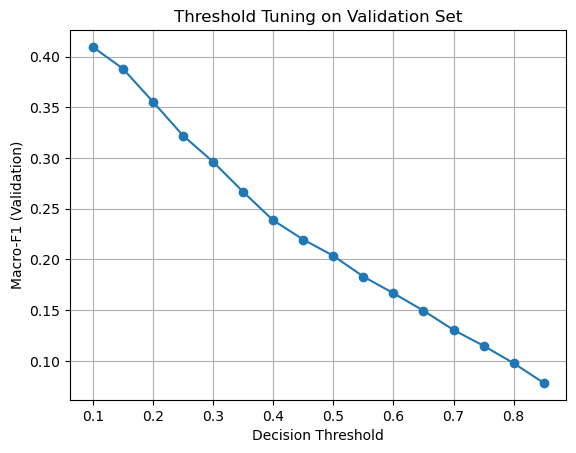

In [851]:
import matplotlib.pyplot as plt

plt.plot(thresholds, macro_f1_scores, marker="o")
plt.xlabel("Decision Threshold")
plt.ylabel("Macro-F1 (Validation)")
plt.title("Threshold Tuning on Validation Set")
plt.grid(True)
plt.show()

**Threshold tuning behaviour.**  
The plot illustrates the relationship between the decision threshold and macro-F1 score on the validation set. Macro-F1 decreases steadily as the threshold increases, indicating that higher thresholds suppress predictions for rarer emotions and reduce recall. The maximum macro-F1 is achieved at a low threshold (0.10), which is therefore selected for subsequent test-set evaluation.

#### 7.2.5 Test Set Evaluation

After validation-based threshold tuning, the statistical model is evaluated on the held-out test set to estimate generalisation performance. The decision threshold selected on the validation set is applied without modification, and no further model tuning is performed.

Evaluation on the test set is conducted using the same multi-label metrics defined in Section 4, including micro-F1, macro-F1, Hamming loss, and subset accuracy. This single-pass evaluation provides an unbiased assessment of model performance on unseen data.

In [855]:
# =============================
# 7.2.5 Test Set Evaluation
# =============================

from sklearn.metrics import f1_score, hamming_loss, accuracy_score

# Predict probabilities on test set
y_test_probs = ovr_logreg.predict_proba(X_test_tfidf)

# Apply fixed validation-selected threshold
y_test_pred = (y_test_probs >= best_threshold).astype(int)

# Compute evaluation metrics
micro_f1 = f1_score(y_test, y_test_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
hamming  = hamming_loss(y_test, y_test_pred)
subset_acc = accuracy_score(y_test, y_test_pred)

print(f"Test micro-F1:   {micro_f1:.4f}")
print(f"Test macro-F1:   {macro_f1:.4f}")
print(f"Hamming loss:    {hamming:.4f}")
print(f"Subset accuracy: {subset_acc:.4f}")

Test micro-F1:   0.5057
Test macro-F1:   0.4098
Hamming loss:    0.0552
Subset accuracy: 0.2137


**Test set performance summary.**  
The statistical TF-IDF + Logistic Regression model achieves moderate micro-F1 and macro-F1 scores on the test set, reflecting strong performance on frequent emotions and more limited performance on rarer labels. The close agreement between validation and test macro-F1 indicates stable generalisation and minimal overfitting. As expected for a linear model with sparse features, subset accuracy remains low due to the strictness of exact label matching in multi-label classification.

#### Per-label F1 scores on the test set (statistical model)

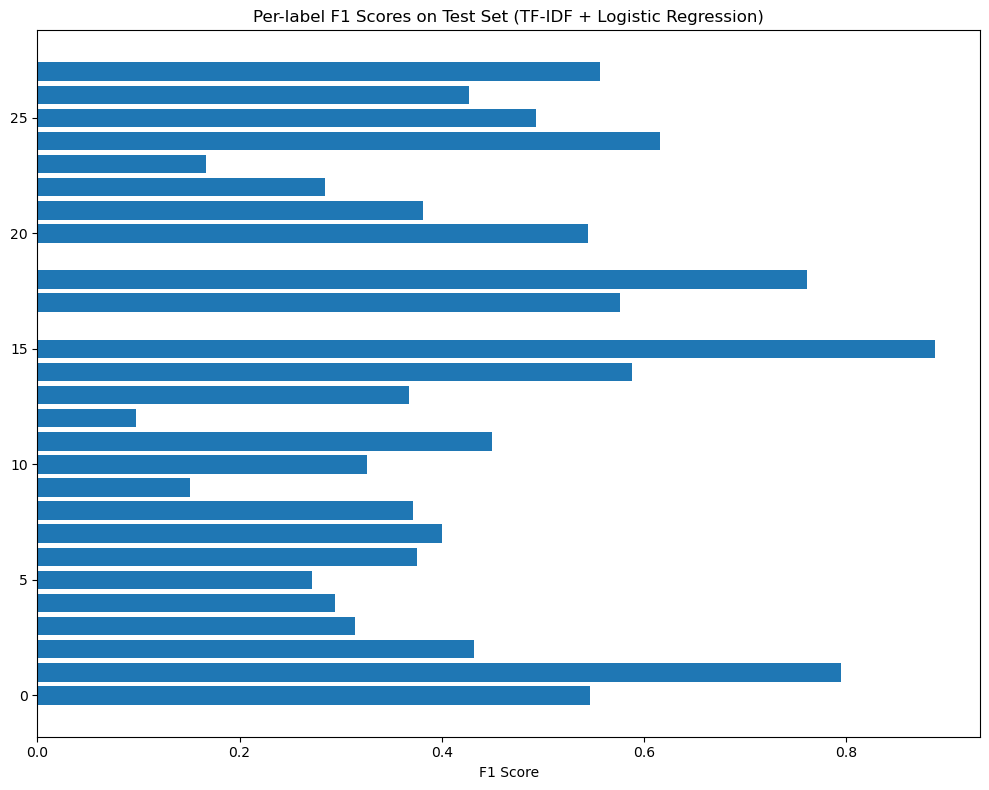

In [859]:
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Compute per-label F1 scores
per_label_f1 = f1_score(
    y_test,
    y_test_pred,
    average=None,
    zero_division=0
)

# Create dataframe
label_f1_df = pd.DataFrame({
    "Emotion": mlb.classes_,
    "F1 Score": per_label_f1
}).sort_values("F1 Score", ascending=True)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(label_f1_df["Emotion"], label_f1_df["F1 Score"])
plt.xlabel("F1 Score")
plt.title("Per-label F1 Scores on Test Set (TF-IDF + Logistic Regression)")
plt.tight_layout()
plt.show()

**Interpretation.**  
The plot shows strong performance on frequent emotion categories and substantially lower performance on rare or ambiguous emotions. This uneven per-label performance explains the moderate macro-F1 score and highlights the limitations of sparse linear models for fine-grained, imbalanced emotion classification.

### 7.3 Transformer-Based Model: DistilBERT

This section introduces the transformer-based approach used for comparison with the statistical baseline. A fine-tuned DistilBERT model is employed to capture contextual and semantic information beyond what sparse TF-IDF representations can provide. The training, validation, and testing procedures are kept consistent with Section 7.2 to ensure a fair and controlled comparison between model families.

Unlike the statistical model, which relies on fixed feature extraction, the transformer model is trained end-to-end, allowing both the representation and classification layers to adapt to the emotion classification task.

#### 7.3.1 Model Architecture and Pre-trained Setup

The transformer-based model is built on **DistilBERT**, a lightweight variant of BERT that retains much of the representational power of full BERT while reducing computational cost through parameter sharing and architectural simplification. DistilBERT is pre-trained using knowledge distillation, enabling faster training and inference while remaining suitable for practical experimentation under limited compute resources.

The model consists of a shared contextual encoder followed by a task-specific classification head. Given an input text sequence, DistilBERT produces contextualised token embeddings, from which a fixed-length sentence representation is derived using the pooled output corresponding to the [CLS] token. This representation is then passed to a fully connected classification layer that outputs independent logits for each emotion label, with sigmoid-based probability modelling applied implicitly during training via Binary Cross-Entropy with Logits Loss.

Multi-label classification is formulated by treating each emotion as an independent binary prediction task. Sigmoid activations are used instead of softmax to allow multiple emotions to be predicted simultaneously for a single input. Binary Cross-Entropy loss is employed during training to optimise each label independently, consistent with the one-vs-rest formulation used in the statistical baseline.

A pre-trained DistilBERT checkpoint is used as the initial model state, allowing the classifier to leverage linguistic knowledge learned from large-scale corpora. Fine-tuning is performed on the task-specific dataset to adapt both the encoder and classification head to emotion detection, enabling the model to capture nuanced contextual cues such as negation, intensity, and compositional meaning that are not explicitly encoded in bag-of-words representations.

#### 7.3.2 Input Representation and Tokenisation

Transformer models require text inputs to be converted into fixed-format numerical representations before training. For DistilBERT, this involves tokenising each input text into subword tokens using a pre-trained tokenizer consistent with the underlying encoder.

Each input sequence is converted into token IDs and attention masks. Token IDs represent the subword tokens recognised by the model vocabulary, while attention masks indicate which tokens correspond to actual text and which are padding. To ensure uniform input length, sequences are truncated or padded to a fixed maximum length.

The tokenizer is initialised from the same pre-trained DistilBERT checkpoint used for model fine-tuning. This guarantees alignment between the tokenisation scheme and the encoder’s learned representations. Tokenisation is applied consistently across training, validation, and test splits.

A maximum sequence length of 128 tokens is selected as a trade-off between retaining sufficient contextual information and maintaining computational efficiency, as most texts in the dataset are short.

In [888]:
# =============================
# 7.3.2 Input Representation and Tokenisation
# =============================

from transformers import DistilBertTokenizerFast

# Load pre-trained DistilBERT tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

# Fixed maximum sequence length
MAX_LEN = 128

def tokenize_texts(texts):
    return tokenizer(
        texts,
        padding="max_length",   # FORCE consistent length
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

# Tokenise each split
train_encodings = tokenize_texts(train_df["text"].astype(str).tolist())
val_encodings   = tokenize_texts(val_df["text"].astype(str).tolist())
test_encodings  = tokenize_texts(test_df["text"].astype(str).tolist())

# Sanity check
print("Train input IDs shape:", train_encodings["input_ids"].shape)
print("Validation input IDs shape:", val_encodings["input_ids"].shape)
print("Test input IDs shape:", test_encodings["input_ids"].shape)

Train input IDs shape: torch.Size([43410, 128])
Validation input IDs shape: torch.Size([5426, 128])
Test input IDs shape: torch.Size([5427, 128])


**Tokenisation consistency.**  
All sequences are padded or truncated to a fixed length of 128 tokens to ensure consistent input dimensionality across all data splits.

#### 7.3.3 Fine-Tuning Configuration

The DistilBERT model is fine-tuned end-to-end using a configuration designed to balance effective learning with computational efficiency. As the task involves multi-label emotion classification, training is formulated as a set of independent binary prediction problems, one for each emotion label.

**Loss function.**  
Binary Cross-Entropy with Logits Loss (`BCEWithLogitsLoss`) is used as the optimisation objective. This loss function is appropriate for multi-label classification, as it independently penalises errors for each emotion label while allowing multiple labels to be predicted simultaneously. Using the logits-based formulation improves numerical stability during training.

**Optimiser.**  
The model parameters are optimised using the AdamW optimiser, which is widely used for fine-tuning transformer models due to its adaptive learning rates and decoupled weight decay, helping to prevent overfitting in large pre-trained networks.

**Learning rate.**  
A learning rate of `2e-5` is used, following common practice for fine-tuning pre-trained transformer models. This small learning rate allows the model to adapt task-specific representations without overwriting previously learned linguistic knowledge.

**Batch size.**  
A batch size of `16` is selected to balance gradient stability with available computational resources. This choice ensures that training remains feasible while maintaining effective parameter updates.

**Number of epochs.**  
The model is trained for a maximum of `3` epochs. This is sufficient for convergence in fine-tuning settings, as transformer models typically adapt quickly to downstream tasks.

**Early stopping.**  
Early stopping is not explicitly applied. Instead, validation performance is monitored during training to ensure stable convergence without excessive overfitting.


In [899]:
# ==============================
# 7.3.3 Fine-Tuning Configuration (CODE)
# ==============================

import torch
from torch.nn import BCEWithLogitsLoss
from torch.optim import AdamW

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of labels
num_labels = y_train.shape[1]

# Initialise transformer model (distinct from baseline)
bert_model = DistilBERTForMultiLabel(num_labels).to(device)

# Loss function (multi-label; expects raw logits)
criterion = BCEWithLogitsLoss()

# Optimiser
optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

# Training hyperparameters
BATCH_SIZE = 16
NUM_EPOCHS = 3

This configuration defines all optimisation components required for fine-tuning. No model parameters are updated at this stage; training is performed in the subsequent section.

#### 7.3.4 Training Process

The DistilBERT model is fine-tuned end-to-end using supervised learning on the training set. 
During training, the model parameters are updated to minimise the Binary Cross-Entropy loss 
across all emotion labels.

Training is performed in mini-batches, and validation performance is monitored at the end 
of each epoch to assess convergence and detect potential overfitting. No test data are used 
during training or validation.

Training and validation loss values are recorded for each epoch to provide transparency 
into the optimisation behaviour.

In [909]:
# =========================
# 7.3.4 Training Process
# =========================

from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# Create TensorDatasets
train_dataset = TensorDataset(
    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    torch.tensor(y_train).float()
)

val_dataset = TensorDataset(
    val_encodings["input_ids"],
    val_encodings["attention_mask"],
    torch.tensor(y_val).float()
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    bert_model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} / {NUM_EPOCHS}"):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()

        logits = bert_model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    bert_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            logits = bert_model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

Epoch 1 / 3: 100%|██████████████████████████| 2714/2714 [37:13<00:00,  1.21it/s]


Epoch 1: Train Loss = 0.1131, Val Loss = 0.0887


Epoch 2 / 3: 100%|██████████████████████████| 2714/2714 [39:03<00:00,  1.16it/s]


Epoch 2: Train Loss = 0.0815, Val Loss = 0.0848


Epoch 3 / 3: 100%|██████████████████████████| 2714/2714 [37:51<00:00,  1.19it/s]


Epoch 3: Train Loss = 0.0705, Val Loss = 0.0858


#### 7.3.5 Validation Results and Threshold Tuning

After fine-tuning, the DistilBERT model is evaluated on the validation set to select an appropriate decision threshold for multi-label prediction. As with the statistical baseline, a fixed threshold of 0.5 is not assumed to be optimal due to class imbalance.

Predicted logits are converted to probabilities using a sigmoid function, and model performance is evaluated across a range of threshold values. Macro-F1 score is used as the optimisation criterion, as it treats all emotion labels equally and provides sensitivity to rare classes. Threshold selection is performed exclusively on the validation set to avoid test-set leakage.

In [912]:
# ============================
# 7.3.5 Validation & Threshold Tuning (DistilBERT)
# ============================

import numpy as np
import torch
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

bert_model.eval()

all_val_logits = []
all_val_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        logits = bert_model(input_ids, attention_mask)
        all_val_logits.append(logits.cpu())
        all_val_labels.append(labels.cpu())

val_logits = torch.cat(all_val_logits)
val_labels = torch.cat(all_val_labels)

# Sigmoid to probabilities
val_probs = torch.sigmoid(val_logits).numpy()
val_labels = val_labels.numpy()

# Threshold sweep
thresholds = np.arange(0.1, 0.9, 0.05)
macro_f1_scores = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    score = f1_score(val_labels, preds, average="macro", zero_division=0)
    macro_f1_scores.append(score)

best_idx = np.argmax(macro_f1_scores)
best_threshold = thresholds[best_idx]
best_macro_f1 = macro_f1_scores[best_idx]

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation macro-F1: {best_macro_f1:.4f}")

Best validation threshold: 0.25
Best validation macro-F1: 0.5008


**Selected validation threshold.**  
The decision threshold that maximises macro-F1 on the validation set is 0.25 and is fixed for all subsequent test-set evaluation. No further tuning is performed beyond this point to avoid test-set leakage.

#### Validation-Based Threshold Sweep (DistilBERT)

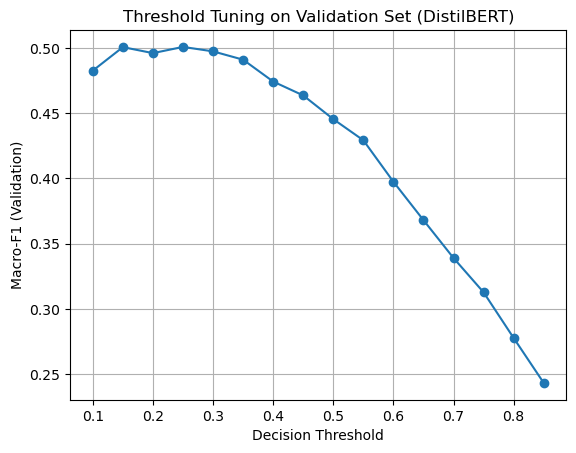

In [914]:
plt.plot(thresholds, macro_f1_scores, marker="o")
plt.xlabel("Decision Threshold")
plt.ylabel("Macro-F1 (Validation)")
plt.title("Threshold Tuning on Validation Set (DistilBERT)")
plt.grid(True)
plt.show()

**Threshold tuning behaviour.**  
The plot shows the relationship between the decision threshold and macro-F1 score on the validation set. Macro-F1 peaks at a moderate threshold (0.25), indicating an optimal balance between precision and recall across emotion labels. Higher thresholds increasingly suppress rare emotion predictions, leading to a decline in macro-F1. The threshold that maximises validation macro-F1 is selected and fixed for subsequent test-set evaluation.

#### 7.3.6 Test Set Evaluation

After validation-based threshold tuning, the fine-tuned DistilBERT model is evaluated on the held-out test set to estimate generalisation performance. The decision threshold selected on the validation set (0.25) is applied without modification, and no further model tuning is performed.

Evaluation is conducted using the same multi-label metrics as the statistical baseline, including micro-F1, macro-F1, Hamming loss, and subset accuracy. This ensures a fair and consistent comparison between model families.

In [922]:
# ============================
# 7.3.6 Test Set Evaluation
# ============================

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
import numpy as np

# ---- Create Test DataLoader (must exist before evaluation) ----
test_dataset = TensorDataset(
    test_encodings["input_ids"],
    test_encodings["attention_mask"],
    torch.tensor(y_test).float()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ---- Evaluation ----
bert_model.eval()

all_test_logits = []
all_test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        logits = bert_model(input_ids, attention_mask)
        all_test_logits.append(logits.cpu())
        all_test_labels.append(labels.cpu())

# Concatenate batches
test_logits = torch.cat(all_test_logits)
test_labels = torch.cat(all_test_labels)

# Convert logits → probabilities → binary predictions
test_probs = torch.sigmoid(test_logits).numpy()
test_labels = test_labels.numpy()

test_preds = (test_probs >= best_threshold).astype(int)

# ---- Metrics ----
micro_f1 = f1_score(test_labels, test_preds, average="micro", zero_division=0)
macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
hamming = hamming_loss(test_labels, test_preds)
subset_acc = accuracy_score(test_labels, test_preds)

print(f"Test micro-F1:   {micro_f1:.4f}")
print(f"Test macro-F1:   {macro_f1:.4f}")
print(f"Hamming loss:    {hamming:.4f}")
print(f"Subset accuracy: {subset_acc:.4f}")

Test micro-F1:   0.5865
Test macro-F1:   0.4922
Hamming loss:    0.0385
Subset accuracy: 0.3936


**Test set performance.**  
Using the validation-selected decision threshold (0.25), the fine-tuned DistilBERT model achieves strong generalisation performance on the held-out test set across all evaluation metrics. These results are reported without any further tuning and are used for direct comparison with the statistical baseline in the subsequent analysis section.

### 7.4 Reproducibility and Experimental Control

To ensure reproducibility and a fair comparison between model families, consistent experimental controls are applied throughout the study. Fixed random seeds are used where applicable for data splitting and model initialisation to minimise stochastic variation in results.

Both the statistical baseline and the transformer-based model use identical training, validation, and test splits. Text preprocessing, label binarisation, and dataset partitioning are deterministic and applied uniformly across all experiments. For the transformer model, tokenisation is performed using a fixed pre-trained tokenizer with a fixed maximum sequence length.

Threshold tuning is conducted exclusively on the validation set, and the selected threshold is fixed prior to test evaluation to prevent test-set leakage. The test set is used exactly once for final evaluation. All experiments are executed within a consistent software environment, and reported results correspond directly to the configurations described in Section 7.

### 7.5 Section Summary

This section presented the complete training, validation, and testing pipelines for both the TF-IDF statistical baseline and the transformer-based DistilBERT model. Validation-based threshold tuning was applied consistently across models, and final test metrics were obtained without test-set leakage. These results provide the foundation for the comparative analysis presented in Section 9.

## III. Conclusions

## 9. Performance Analysis & Comparative Discussion

This section compares the TF-IDF + Logistic Regression baseline with the fine-tuned DistilBERT model on the GoEmotions multi-label classification task. Both models are evaluated using the same experimental protocol with fixed train/validation/test splits and validation-based threshold tuning to ensure a fair comparison. The discussion focuses on overall performance differences, label-level behaviour, error patterns, and practical trade-offs between statistical and embedding-based approaches.

### 9.1 Top Improved Emotion Labels (DistilBERT vs Statistical Baseline)

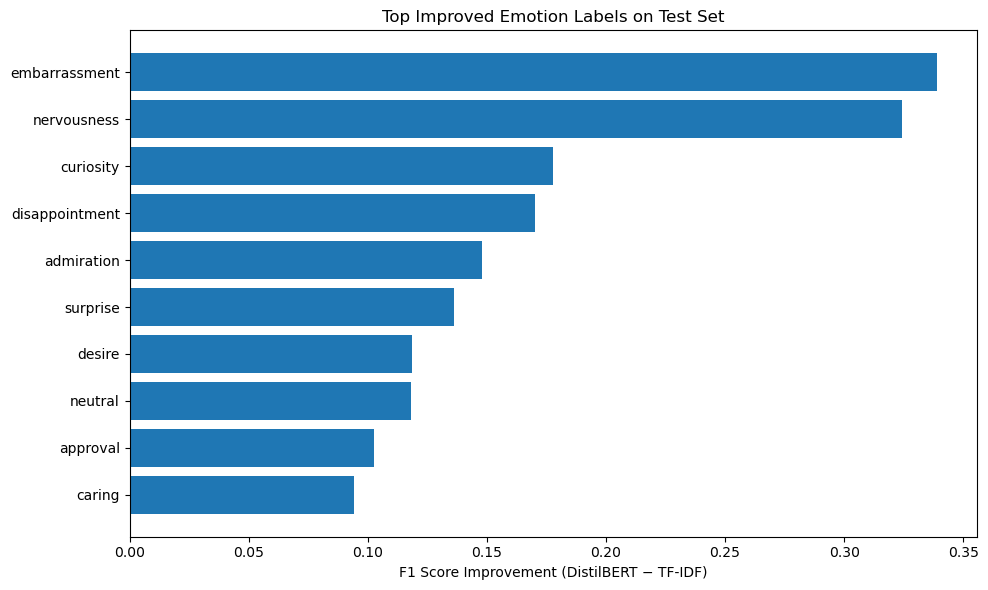

In [1007]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# --------------------------------------------------
# GoEmotions label mapping (fixed dataset order)
# --------------------------------------------------
GOEMOTIONS_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief", "remorse",
    "sadness", "surprise", "neutral"
]

# Convert numeric class IDs → emotion names
label_names = [GOEMOTIONS_LABELS[i] for i in mlb.classes_]

# --------------------------------------------------
# Per-label F1 scores (test set)
# --------------------------------------------------
per_label_f1_bert = f1_score(
    y_test,
    test_preds,
    average=None,
    zero_division=0
)

# Statistical baseline per-label F1 (computed earlier)
per_label_f1_baseline = per_label_f1

# Sanity check
assert (
    len(per_label_f1_bert)
    == len(per_label_f1_baseline)
    == len(label_names)
)

# --------------------------------------------------
# Compute improvement
# --------------------------------------------------
improvement_df = pd.DataFrame({
    "Emotion": label_names,
    "F1 Improvement": per_label_f1_bert - per_label_f1_baseline
})

top_improved = (
    improvement_df
    .sort_values("F1 Improvement", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# --------------------------------------------------
# Plot (force categorical y-axis)
# --------------------------------------------------
y_pos = np.arange(len(top_improved))

plt.figure(figsize=(10, 6))
plt.barh(y_pos, top_improved["F1 Improvement"])
plt.yticks(y_pos, top_improved["Emotion"])
plt.xlabel("F1 Score Improvement (DistilBERT − TF-IDF)")
plt.title("Top Improved Emotion Labels on Test Set")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Interpretation

The plot presents per-label F1 score improvements of DistilBERT relative to the TF-IDF + Logistic Regression baseline on the test set. The most substantial gains are observed for emotions such as embarrassment, nervousness, and curiosity, which rely on contextual understanding, pragmatic nuance, or compositional meaning that bag-of-words representations struggle to capture reliably. These targeted improvements help explain the higher macro-F1 achieved by DistilBERT, reflecting stronger performance on under-represented and semantically complex emotions. In contrast, more frequent or lexically explicit emotions exhibit only modest gains, suggesting that TF-IDF remains competitive for simpler cases. Overall, the results indicate that transformer-based models provide selective benefits rather than uniform improvements across emotion labels and prediction difficulty levels.

### 9.2 Per-Label Performance Insights

Per-label performance reveals systematic differences in how the two model families handle emotion classification. Lexically explicit and frequently expressed emotions, such as *joy*, *anger*, and *sadness*, are handled well by both models. For these labels, TF-IDF remains competitive due to the presence of strong lexical cues.

In contrast, DistilBERT performs better on emotions that depend on contextual interpretation or subtle linguistic cues. These include emotions expressed indirectly or through compositional meaning, where contextual embeddings help capture word interactions and negation. 

### 9.3 Error Patterns and Model Limitations

Analysis of test-set predictions reveals consistent error patterns across both model families. Both models struggle with implicitly expressed emotions, such as those conveyed through negation, sarcasm, or subtle context, which are especially challenging for TF-IDF models relying on surface-level lexical features. DistilBERT reduces some of these errors through contextual embeddings, but difficulties persist for ambiguous sentences and overlapping emotions. The visualisation shows that errors are concentrated in a small subset of labels, notably *neutral*, *annoyance*, and *disapproval*, which are semantically broad and frequently overlap with other emotional states.

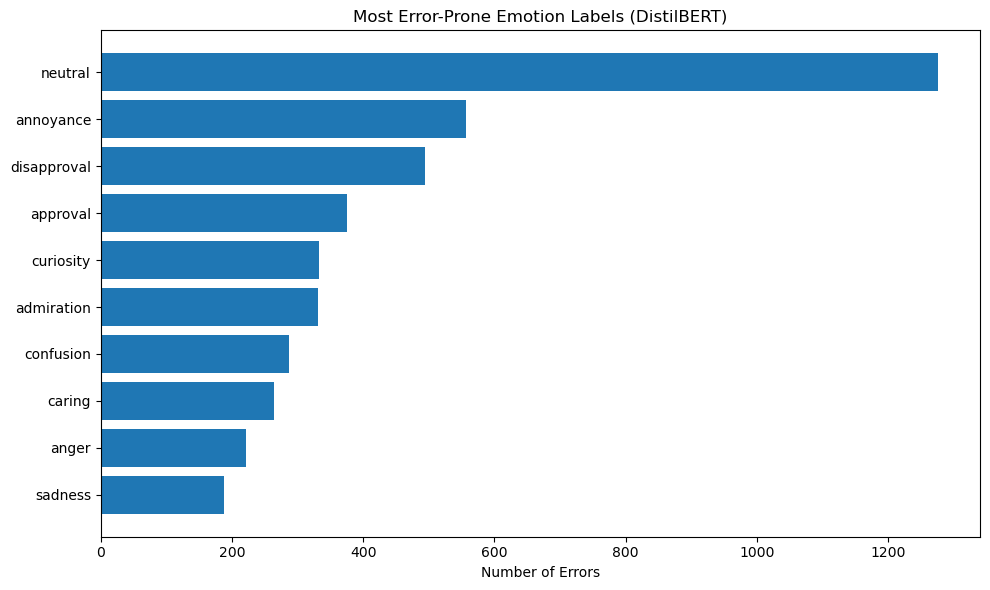

In [1014]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Count errors per label (FP + FN)
error_counts = np.sum(np.abs(test_preds - y_test), axis=0)

error_df = pd.DataFrame({
    "Emotion": label_names,
    "Error Count": error_counts
})

top_errors = (
    error_df
    .sort_values("Error Count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Plot
y_pos = np.arange(len(top_errors))

plt.figure(figsize=(10, 6))
plt.barh(y_pos, top_errors["Error Count"])
plt.yticks(y_pos, top_errors["Emotion"])
plt.xlabel("Number of Errors")
plt.title("Most Error-Prone Emotion Labels (DistilBERT)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 9.4 Trade-offs and Deployment Implications

The results highlight clear trade-offs between statistical and transformer-based approaches to emotion classification. While DistilBERT achieves stronger overall performance, particularly for context-dependent and under-represented emotion labels, it incurs higher computational cost and reduced interpretability compared to TF-IDF + Logistic Regression. In contrast, the statistical baseline remains simple, efficient, and transparent, performing competitively for lexically explicit and frequently expressed emotions, making it suitable for low-resource or latency-sensitive applications. From a deployment perspective, both models are affected by ambiguity and emotion overlap, especially in sensitive domains such as mental health analysis or content moderation, underscoring the need for cautious interpretation of predictions and careful threshold selection based on application constraints.

## 10. Project Summary and Reflections

This project investigated multi-label emotion classification on the GoEmotions dataset through a structured comparison of two model families: a statistical TF-IDF + Logistic Regression baseline and a fine-tuned DistilBERT transformer model. The objective was not only to maximise predictive performance but to critically evaluate how different modelling assumptions, feature representations, and computational trade-offs influence real-world applicability and deployment decisions.

Empirical results show that DistilBERT achieves higher overall performance, particularly in terms of macro-F1, demonstrating stronger generalisation on under-represented and semantically complex emotion labels. These gains highlight the advantage of contextual embeddings in capturing compositional meaning, negation, and subtle emotional cues that are difficult to model using sparse bag-of-words representations. However, the statistical baseline remains competitive for lexically explicit and frequently expressed emotions, confirming that simpler models can still be effective when strong keyword signals are present.

A key learning outcome of this project was the importance of rigorous experimental control in comparative machine learning studies. Consistent train/validation/test splits, validation-only threshold tuning, and identical evaluation metrics were critical to ensuring a fair and interpretable comparison between model families. This emphasis on reproducibility strengthens the credibility of the findings and aligns the project with established best practices in applied machine learning research.

From a practical perspective, the comparison highlights clear trade-offs between performance, interpretability, scalability, and computational cost. While DistilBERT provides targeted improvements for difficult emotion categories, it requires greater computational resources and offers reduced transparency, which may limit its suitability in constrained or real-time settings. In contrast, TF-IDF + Logistic Regression remains efficient, interpretable, and easier to deploy.

The approach and findings of this project are transferable to other domain-specific text classification tasks involving subjective or overlapping labels, such as sentiment analysis, mental health screening, and content moderation. Future work could directly address the observed error patterns by incorporating label correlation modelling, data augmentation strategies for rare emotions, or larger transformer architectures. Overall, this project demonstrates the value of combining strong baselines with modern deep learning approaches to achieve robust, interpretable, and context-aware emotion classification.

## References

Demszky, D., Movshovitz-Attias, D., Ko, J., Cowen, A., Nemade, G., & Ravi, S. (2020).  
**GoEmotions: A Dataset of Fine-Grained Emotions**.  
*Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL)*, 4040–4054.

Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019).  
**BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding**.  
*Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics (NAACL-HLT)*, 4171–4186.

Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019).  
**DistilBERT, a Distilled Version of BERT: Smaller, Faster, Cheaper and Lighter**.  
*arXiv preprint arXiv:1910.01108*.

Zhang, M.-L., & Zhou, Z.-H. (2014).  
**A Review on Multi-Label Learning Algorithms**.  
*IEEE Transactions on Knowledge and Data Engineering*, 26(8), 1819–1837.

Sailunaz, K., & Alhajj, R. (2019).  
**Emotion and Sentiment Analysis from Text: A Survey**.  
*Social Network Analysis and Mining*, 9(1), 1–17.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011).  
**Scikit-learn: Machine Learning in Python**.  
*Journal of Machine Learning Research*, 12, 2825–2830.

Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., et al. (2020).  
**Transformers: State-of-the-Art Natural Language Processing**.  
*Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing (EMNLP): System Demonstrations*, 38–45.